# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the seminar notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [140]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

state vector dim = 4
n_actions = 2


C:\Users\aleksandr.egorov\ml\.venv\lib\site-packages\gymnasium\envs\registration.py:519: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


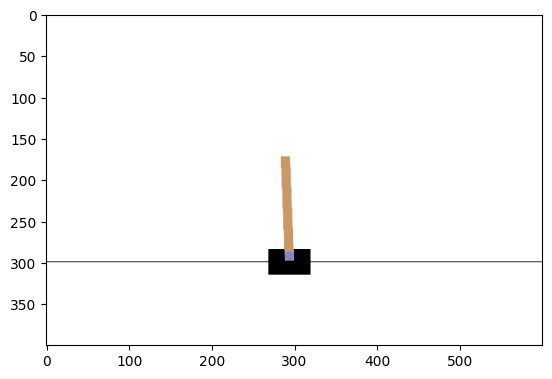

In [141]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__


In [142]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), range(n_actions))


MLPClassifier(activation='tanh', hidden_layer_sizes=(20, 20))

In [143]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:
        probs = agent.predict_proba(s.reshape(1, -1))[0]

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(n_actions, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [144]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[-0.0049407  -0.00729755  0.00976123 -0.02196963]
 [-0.00508665  0.18768308  0.00932184 -0.31155688]
 [-0.00133299 -0.00757044  0.0030907  -0.01594875]
 [-0.0014844   0.18750705  0.00277172 -0.30765492]
 [ 0.00226574  0.3825894  -0.00338137 -0.59946245]]
actions: [1, 0, 1, 1, 1]
reward: 5.0


### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [145]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    reward_threshold = np.percentile(rewards_batch, percentile)
    (elites,) = np.where(rewards_batch >= reward_threshold)

    elite_states = []
    elite_actions = []
    for i in elites:
        elite_states.extend(states_batch[i])
        elite_actions.extend(actions_batch[i])

    return elite_states, elite_actions


# Training loop
Generate sessions, select N best and fit to those.

In [146]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


mean reward = 168.850, threshold=185.000


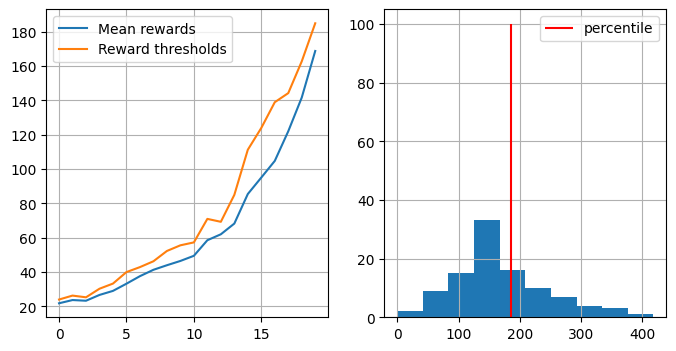

In [147]:
n_sessions = 100
percentile = 70
log = []

for i in range(20):
    # generate new sessions
    sessions = [generate_session(env, agent, t_max=10**4) for _ in range(n_sessions)]

    states_batch = []
    actions_batch = []
    rewards_batch = []
    for session in sessions:
      states_batch.append(session[0])
      actions_batch.append(session[1])
      rewards_batch.append(session[2])

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

    agent.partial_fit(X=elite_states, y=elite_actions)

    show_progress(
        rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now via KeyboardInterrupt.")


# Results

In [53]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("CartPole-v0", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(100)]


C:\Users\aleksandr.egorov\ml\.venv\lib\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning: WARN: Overwriting existing videos at C:\Users\aleksandr.egorov\ml\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [54]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# Homework part I

### Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -100 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (0.1 pts) Find out how the algorithm performance changes if you use a different `percentile` and/or `n_sessions`. Provide here some figures so we can see how the hyperparameters influence the performance.
- __1.2__ (0.1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


**Рассмотрим на примере задачи с такси, для этого добавлю код с семинара**

(314, {'prob': 1.0, 'action_mask': array([1, 1, 0, 0, 0, 0], dtype=int8)})


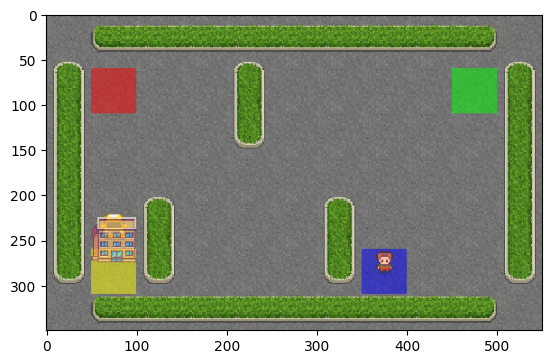

In [148]:
env = gym.make("Taxi-v3", render_mode="rgb_array")
print(env.reset(seed=0))
plt.imshow(env.render())
n_states = env.observation_space.n
n_actions = env.action_space.n

def initialize_policy_tabular(n_states, n_actions):
    #<YOUR CODE: create an array to store action probabilities>
    policy = np.ones((n_states, n_actions)) / n_actions

    return policy




In [149]:
def generate_session_tabular(env, policy, t_max=10**4):
    """
    Play game until end or for t_max ticks.
    :param policy: an array of shape [n_states,n_actions] with action probabilities
    :returns: list of states, list of actions and sum of rewards
    """
    states, actions = [], []
    total_reward = 0.0

    s, _ = env.reset()

    for t in range(t_max):
        # Hint: you can use np.random.choice for sampling action
        # https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html

        a = np.random.choice(n_actions, p=policy[s]) #<YOUR CODE: sample action from policy>

        new_s, r, terminated, truncated, _ = env.step(a)

        # Record information we just got from the environment.
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break

    return states, actions, total_reward

In [150]:
def get_new_policy_tabular(elite_states, elite_actions):
    """
    Given a list of elite states/actions from select_elites,
    return a new policy where each action probability is proportional to

        policy[s_i,a_i] ~ #[occurrences of s_i and a_i in elite states/actions]

    Don't forget to normalize the policy to get valid probabilities and handle the 0/0 case.
    For states that you never visited, use a uniform distribution (1/n_actions for all states).

    :param elite_states: 1D list of states from elite sessions
    :param elite_actions: 1D list of actions from elite sessions

    """

    new_policy = np.zeros([n_states, n_actions])

    #<YOUR CODE: set probabilities for actions given elite states & actions>
    # Don't forget to set 1/n_actions for all actions in unvisited states.
    for s, a in zip(elite_states, elite_actions):
        new_policy[s, a] += 1

    new_policy[np.where(new_policy.sum(axis=1) == 0)] = 1
    new_policy = new_policy / new_policy.sum(axis=1, keepdims=True)

    return new_policy

mean reward = -151.400, threshold=-24.500


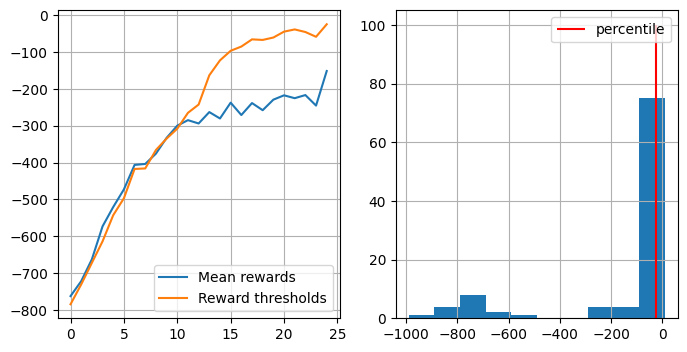

learning_rate=0.5
percentile=50
n_sessions=100


In [75]:
n_sessions = 100  # sample this many sessions
percentile = 50  # discard this percentage of sessions with lowest rewards
learning_rate = 0.99  # how quickly the policy is updated, on a scale from 0 to 1

log = []
env.reset()
policy = initialize_policy_tabular(n_states, n_actions)

for i in range(25):
    %time sessions = [ generate_session_tabular(env, policy, t_max=10**4) for _ in range(n_sessions)] #<YOUR CODE: generate a list of n_sessions new sessions> ]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile) #<YOUR CODE: select elite states & actions>

    new_policy = get_new_policy_tabular(elite_states, elite_actions) #<YOUR CODE: compute new policy>

    policy = learning_rate * new_policy + (1 - learning_rate) * policy

    # display results on chart
    show_progress(rewards_batch, log, percentile)
    print(f"{learning_rate=}")
    print(f"{percentile=}")
    print(f"{n_sessions=}")



    learning_rate -= 0.05
    learning_rate = max([0.5, learning_rate])

mean reward = -2.708, threshold=5.000


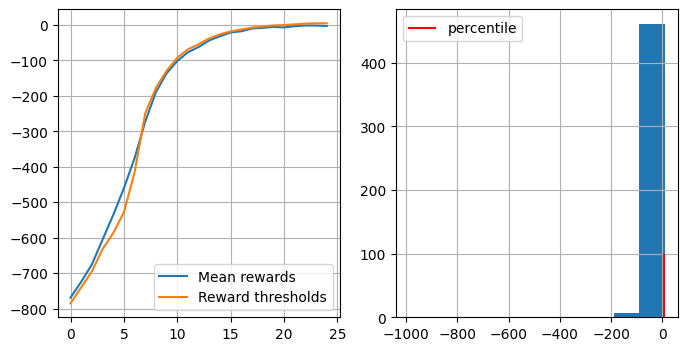

learning_rate=0.5
percentile=50
n_sessions=500


In [80]:
n_sessions = 500  # sample this many sessions
percentile = 50  # discard this percentage of sessions with lowest rewards
learning_rate = 0.99  # how quickly the policy is updated, on a scale from 0 to 1
env.reset()
policy = initialize_policy_tabular(n_states, n_actions)
log = []

for i in range(25):
    %time sessions = [ generate_session_tabular(env, policy, t_max=10**4) for _ in range(n_sessions)] #<YOUR CODE: generate a list of n_sessions new sessions> ]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile) #<YOUR CODE: select elite states & actions>

    new_policy = get_new_policy_tabular(elite_states, elite_actions) #<YOUR CODE: compute new policy>

    policy = learning_rate * new_policy + (1 - learning_rate) * policy

    # display results on chart
    show_progress(rewards_batch, log, percentile)
    print(f"{learning_rate=}")
    print(f"{percentile=}")
    print(f"{n_sessions=}")



    learning_rate -= 0.05
    learning_rate = max([0.5, learning_rate])

mean reward = -316.660, threshold=-12.400


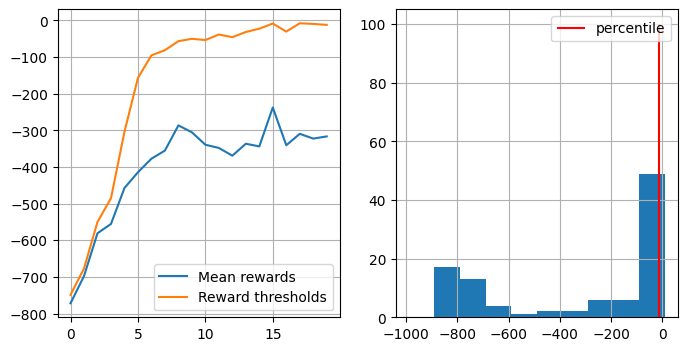

learning_rate=0.5
percentile=70
n_sessions=100


In [79]:
n_sessions = 100  # sample this many sessions
percentile = 70  # discard this percentage of sessions with lowest rewards
learning_rate = 0.99  # how quickly the policy is updated, on a scale from 0 to 1
env.reset()
policy = initialize_policy_tabular(n_states, n_actions)
log = []

for i in range(25):
    %time sessions = [ generate_session_tabular(env, policy, t_max=10**4) for _ in range(n_sessions)] #<YOUR CODE: generate a list of n_sessions new sessions> ]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile) #<YOUR CODE: select elite states & actions>

    new_policy = get_new_policy_tabular(elite_states, elite_actions) #<YOUR CODE: compute new policy>

    policy = learning_rate * new_policy + (1 - learning_rate) * policy

    # display results on chart
    show_progress(rewards_batch, log, percentile)
    print(f"{learning_rate=}")
    print(f"{percentile=}")
    print(f"{n_sessions=}")



    learning_rate -= 0.05
    learning_rate = max([0.5, learning_rate])

mean reward = -636.370, threshold=-20.500


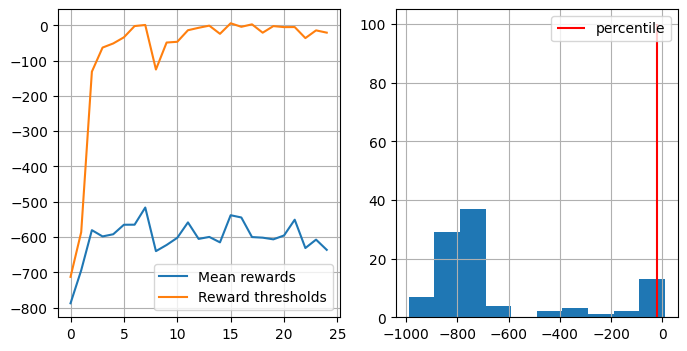

learning_rate=0.5
percentile=90
n_sessions=100


In [151]:
n_sessions = 100  # sample this many sessions
percentile = 90  # discard this percentage of sessions with lowest rewards
learning_rate = 0.99  # how quickly the policy is updated, on a scale from 0 to 1
env.reset()
policy = initialize_policy_tabular(n_states, n_actions)
log = []

for i in range(25):
    %time sessions = [ generate_session_tabular(env, policy, t_max=10**4) for _ in range(n_sessions)] #<YOUR CODE: generate a list of n_sessions new sessions> ]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile) #<YOUR CODE: select elite states & actions>

    new_policy = get_new_policy_tabular(elite_states, elite_actions) #<YOUR CODE: compute new policy>

    policy = learning_rate * new_policy + (1 - learning_rate) * policy

    # display results on chart
    show_progress(rewards_batch, log, percentile)
    print(f"{learning_rate=}")
    print(f"{percentile=}")
    print(f"{n_sessions=}")



    learning_rate -= 0.05
    learning_rate = max([0.5, learning_rate])

**Вывод: при увеличении количества сессий выше качество обучения, так как данные более разнообразные (при этом скорость падает и увеличивать количество сессий в бесконечность не вариант). При увеличении перцентиля при выборе элит ситуация обратная - ниже разнообразие и хуже качество. При этом неплохо себя показывает ситуация, если сначала брать большой перцентиль, а потом уменьшать его во время обучения. Это гиперпараметры, которые стоит подбирать**

mean reward = 3.518, threshold=1.000


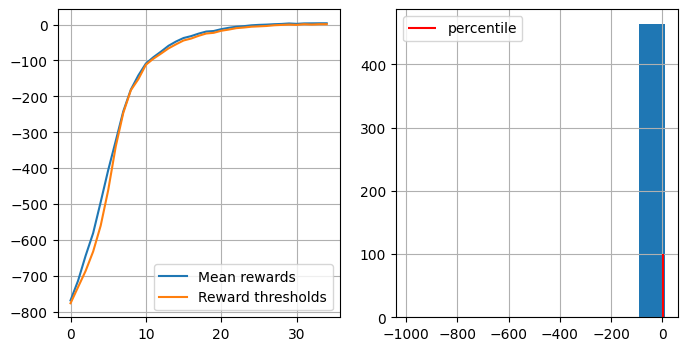

learning_rate=0.5
percentile=16
n_sessions=500


In [84]:
n_sessions = 500  # sample this many sessions
percentile = 50  # discard this percentage of sessions with lowest rewards
learning_rate = 0.99  # how quickly the policy is updated, on a scale from 0 to 1
env.reset()
policy = initialize_policy_tabular(n_states, n_actions)
log = []

for i in range(35):
    %time sessions = [ generate_session_tabular(env, policy, t_max=10**4) for _ in range(n_sessions)] #<YOUR CODE: generate a list of n_sessions new sessions> ]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile) #<YOUR CODE: select elite states & actions>

    new_policy = get_new_policy_tabular(elite_states, elite_actions) #<YOUR CODE: compute new policy>

    policy = learning_rate * new_policy + (1 - learning_rate) * policy

    # display results on chart
    show_progress(rewards_batch, log, percentile)
    print(f"{learning_rate=}")
    print(f"{percentile=}")
    print(f"{n_sessions=}")



    learning_rate -= 0.05
    learning_rate = max([0.5, learning_rate])
    percentile -= 1

**Чтобы добиться положительного reward скомбинируем - возьмем достаточно сессий(500) и будем уменьшать percentile на 1 пункт каждую эпоху обучения**

# Homework part II

### Deep crossentropy method

By this moment, you should have got enough score on [CartPole-v0](https://gymnasium.farama.org/environments/classic_control/cart_pole/) to consider it solved (see the link). It's time to try something harder.

* if you have any trouble with CartPole-v0 and feel stuck, feel free to ask us or your peers for help.

### Tasks

* __2.1__ (0.3 pts) Pick one of environments: `MountainCar-v0` or `LunarLander-v2`.
  * For MountainCar, get average reward of __at least -150__
  * For LunarLander, get average reward of __at least +50__

See the tips section below, it's kinda important.
__Note:__ If your agent is below the target score, you'll still get some of the points depending on the result, so don't be afraid to submit it.
  
  
* __2.2__ (up to 0.5 pts) Devise a way to speed up training against the default version
  * Obvious improvement: use [`joblib`](https://joblib.readthedocs.io/en/latest/). However, note that you will probably need to spawn a new environment in each of the workers instead of passing it via pickling. (0.1 pts)
  * Try re-using samples from 3-5 last iterations when computing threshold and training. (0.2 pts)
  * Obtain __-100__ at `MountainCar-v0` or __+200__ at `LunarLander-v2` (0.2 pts). Feel free to experiment with hyperparameters, architectures, schedules etc.  
  
### Tips
* Gymnasium pages: [MountainCar](https://gymnasium.farama.org/environments/classic_control/mountain_car/), [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
* Sessions for MountainCar may last for 10k+ ticks. Make sure ```t_max``` param is at least 10k.
 * Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better, than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
* _issue with gym_: Some versions of gym limit game time by 200 ticks. This will prevent cem training in most cases. Make sure your agent is able to play for the specified __t_max__, and if it isn't, try `env = gym.make("MountainCar-v0").env` or otherwise get rid of TimeLimit wrapper.
* If you use old _swig_ lib for LunarLander-v2, you may get an error. See this [issue](https://github.com/openai/gym/issues/100) for solution.
* If it doesn't train, it's a good idea to plot reward distribution and record sessions: they may give you some clue. If they don't, call course staff :)
* 20-neuron network is probably not enough, feel free to experiment.

You may find the following snippet useful:

state vector dim = 2
n_actions = 3


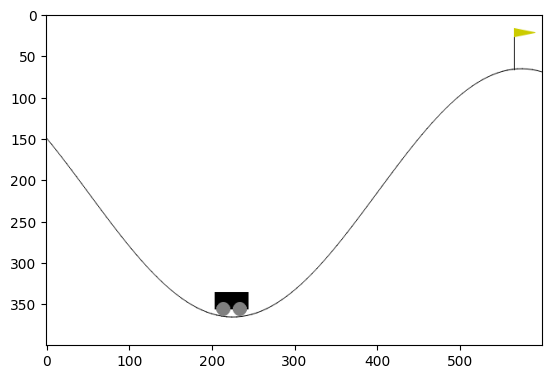

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("MountainCar-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

In [70]:
from sklearn.neural_network import MLPClassifier
env = gym.make("MountainCar-v0").env
agent = MLPClassifier(
            hidden_layer_sizes=(20, 10, 20),
            activation='tanh',
            warm_start=True,
            max_iter=1)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), range(n_actions))

MLPClassifier(activation='tanh', hidden_layer_sizes=(20, 10, 20), max_iter=1,
              warm_start=True)

In [5]:
def generate_session(t_max, agent, env):
    states, actions = [], []
    total_reward = 0
    real_reward = 0
    s = env.reset()[0]

    for t in range(t_max):

        # predict array of action probabilities
        probs = agent.predict_proba(s.reshape(1, -1))[0]

        a = np.random.choice(env.action_space.n, p=probs)

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += (r + 300 * (abs(new_s[1]) - abs(s[1]))) # идея отсюда https://habr.com/ru/companies/hsespb/articles/444428/
        real_reward += r 

        s = new_s
        if terminated or truncated:
            break

    return states, actions, total_reward, t, real_reward


mean reward = -105.580, threshold=-106.000


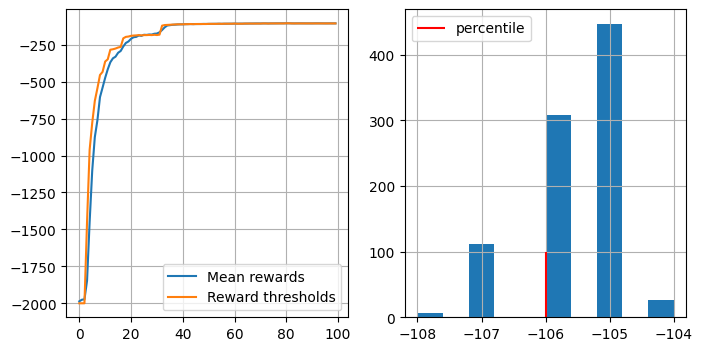

In [72]:
import time
from joblib import Parallel, delayed
from collections import deque 

n_sessions = 300
percentile = 90
n_jobs=-1
log = []
t_max=10**5

session_buffer = deque([])

for i in range(100):
    # generate new sessions
    sessions = Parallel(n_jobs=n_jobs)(delayed(generate_session)(env=env, agent=agent, t_max=t_max) for j in range(n_sessions))
    session_buffer.append(sessions)
        
    states_batch = []
    actions_batch = []
    rewards_batch = []
    real_rewards_batch = []
    for i in session_buffer:
        for session in sessions:
          states_batch.append(session[0])
          actions_batch.append(session[1])
          rewards_batch.append(session[2])
          real_rewards_batch.append(session[4])
    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
    agent.partial_fit(X=elite_states, y=elite_actions)
    show_progress(
        real_rewards_batch, log, percentile, reward_range=[np.min(real_rewards_batch), np.max(real_rewards_batch)]
    )
    if len(session_buffer) == 3:
        session_buffer.popleft()
    if percentile>=30:
        percentile -= 1
    if np.mean(real_rewards_batch) > -100:
        print("You Win! You may stop training now via KeyboardInterrupt.")

Что применил:
- joblib
- Сохранение 3х последних сессий в буфер для ускорения
- метод потенциалов отсюда https://habr.com/ru/companies/hsespb/articles/444428/
- линейное уменьшение percentile с 90 до 30 во время обучения
- hidden_layer_sizes(20, 10, 20)

### Bonus tasks

* __2.3 bonus__ (0.2 pts) Try to find a network architecture and training params that solve __both__ environments above. 

* __2.4 bonus__ (0.3 pts) Solve continuous action space task with `MLPRegressor` or similar.
  * Since your agent only predicts the "expected" action, you will have to add noise to ensure exploration.
  * Choose one of [MountainCarContinuous-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/) (90+ pts to solve), [LunarLanderContinuous-v2](https://gymnasium.farama.org/environments/box2d/lunar_lander/) (`env = gym.make("LunarLander-v2", continuous=True)`)(200+ pts to solve)
  * 0.3 points for solving. Slightly less for getting some results below solution threshold. Note that discrete and continuous environments may have slightly different rules, aside from action spaces.

Решаю задачу для MountainCarContinuous-v0.

Агента взял отсюда и доработал до рабочего состояния: https://goodboychan.github.io/python/reinforcement_learning/pytorch/udacity/2021/05/11/CEM-MountainCar.html

In [173]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make('MountainCarContinuous-v0')

print('observation space:', env.observation_space)
print('action space:', env.action_space)

env.close()

observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
action space: Box(-1.0, 1.0, (1,), float32)


In [174]:
import torch
import torch.nn as nn
import torch.nn.functional as F


In [175]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [176]:
class Agent(nn.Module):
    def __init__(self, env, h_size=16):
        super().__init__()
        self.env = env
        # state, hidden layer, action sizes
        self.s_size = env.observation_space.shape[0]
        self.h_size = h_size
        self.a_size = env.action_space.shape[0]
        # define layers (we used 2 layers)
        self.fc1 = nn.Linear(self.s_size, self.h_size)
        self.fc2 = nn.Linear(self.h_size, self.a_size)
        
    def set_weights(self, weights):
        s_size = self.s_size
        h_size = self.h_size
        a_size = self.a_size
        # separate the weights for each layer
        fc1_end = (s_size * h_size) + h_size
        fc1_W = torch.from_numpy(weights[:s_size*h_size].reshape(s_size, h_size))
        fc1_b = torch.from_numpy(weights[s_size*h_size:fc1_end])
        fc2_W = torch.from_numpy(weights[fc1_end:fc1_end+(h_size*a_size)].reshape(h_size, a_size))
        fc2_b = torch.from_numpy(weights[fc1_end+(h_size*a_size):])
        # set the weights for each layer
        self.fc1.weight.data.copy_(fc1_W.view_as(self.fc1.weight.data))
        self.fc1.bias.data.copy_(fc1_b.view_as(self.fc1.bias.data))
        self.fc2.weight.data.copy_(fc2_W.view_as(self.fc2.weight.data))
        self.fc2.bias.data.copy_(fc2_b.view_as(self.fc2.bias.data))
    
    def get_weights_dim(self):
        return (self.s_size + 1) * self.h_size + (self.h_size + 1) * self.a_size
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        return x.cpu().data
    
    def act(self, s):
        state = torch.from_numpy(s).float().to(device)
        with torch.no_grad():
            action = self.forward(s)
        return action
        
    def evaluate(self, weights, max_t=5000):
        self.set_weights(weights)
        reward = 0.0
        s = self.env.reset()[0]
        for t in range(max_t):
            s = torch.from_numpy(s).float().to(device)
            action = self.forward(s)
            s, r, terminated, truncated, _ = self.env.step(action.numpy())
            reward += r
            if terminated or truncated:
                break
        return reward

In [177]:
def generate_session_continious(t_max, agent, best_weight):
    weights = best_weight + 0.5 * np.random.randn(agent.get_weights_dim())
    reward = agent.evaluate(weights, t_max)
        
    return weights, reward

def select_elites_continious(weights_batch, rewards_batch, percentile):
    reward_threshold = np.percentile(rewards_batch, percentile)
    (elites,) = np.where(rewards_batch >= reward_threshold)
    elite_weights = []
    for i in elites:
        elite_weights.append(weights_batch[i])
    best_weight = np.array(elite_weights).mean(axis=0)
    return best_weight

In [138]:
from collections import deque
t_max = 1000
rewards = deque(maxlen=100)
agent = Agent(env).to(device)
best_weight = 0.5*np.random.randn(agent.get_weights_dim())
percentile = 80
n_sessions = 50

for i in range(500):
    rewards_batch = []
    weights_batch = []
    sessions = Parallel(n_jobs=n_jobs)(delayed(generate_session_continious)(agent=agent, t_max=t_max, best_weight=best_weight) for j in range(n_sessions))
    for session in sessions:
           weights_batch.append(session[0])
           rewards_batch.append(session[1])                        
    best_weight = select_elites_continious(weights_batch, rewards_batch, percentile=percentile)
    reward = agent.evaluate(best_weight)
    rewards.append(reward)
                
    if i % 10 == 0:
        print('Episode {}\tAverage Score: {:.2f}'.format(i, np.mean(rewards)))
    
    if np.mean(rewards)>=90.0:
        print('\nEnvironment solved in {:d} iterations!\tAverage Score: {:.2f}'.format(i-100, np.mean(rewards)))
        break


Episode 0	Average Score: -1.53
Episode 10	Average Score: 11.28
Episode 20	Average Score: 34.96
Episode 30	Average Score: 53.39
Episode 40	Average Score: 63.08
Episode 50	Average Score: 69.26
Episode 60	Average Score: 73.46
Episode 70	Average Score: 76.44
Episode 80	Average Score: 78.64
Episode 90	Average Score: 80.48
Episode 100	Average Score: 82.51

Environment solved in 8 iterations!	Average Score: 90.18


**Эта же архитектура и параметры справляются со второй задачей LunarLander-v3**

In [168]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

env = env = gym.make("LunarLander-v3", continuous=True)

print('observation space:', env.observation_space)
print('action space:', env.action_space)

env.close()

observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
action space: Box(-1.0, 1.0, (2,), float32)


In [172]:
from collections import deque
t_max = 1000
rewards = deque(maxlen=100)
agent = Agent(env).to(device)
best_weight = 0.5*np.random.randn(agent.get_weights_dim())
percentile = 80
n_sessions = 50

for i in range(500):
    rewards_batch = []
    weights_batch = []
    sessions = Parallel(n_jobs=n_jobs)(delayed(generate_session_continious)(agent=agent, t_max=t_max, best_weight=best_weight) for j in range(n_sessions))
    for session in sessions:
           weights_batch.append(session[0])
           rewards_batch.append(session[1])                        
    best_weight = select_elites_continious(weights_batch, rewards_batch, percentile=percentile)
    reward = agent.evaluate(best_weight)
    rewards.append(reward)
                
    if i % 10 == 0:
        print('Episode {}\tAverage Score: {:.2f}'.format(i, np.mean(rewards)))
    
    if np.mean(rewards)>200.0:
        print('\nEnvironment solved in {:d} iterations!\tAverage Score: {:.2f}'.format(i-100, np.mean(rewards)))
        break


Episode 0	Average Score: -185.73
Episode 10	Average Score: -126.34
Episode 20	Average Score: -92.37
Episode 30	Average Score: -70.45
Episode 40	Average Score: -47.42
Episode 50	Average Score: -30.01
Episode 60	Average Score: -14.73
Episode 70	Average Score: 19.33
Episode 80	Average Score: 46.72
Episode 90	Average Score: 67.94
Episode 100	Average Score: 88.98
Episode 110	Average Score: 118.45
Episode 120	Average Score: 148.60
Episode 130	Average Score: 178.46
Episode 140	Average Score: 201.09

Environment solved in 40 iterations!	Average Score: 201.09
